In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score

In [3]:
X = pd.read_csv('D:\VSCODE\Project_Songs_Clustering\Music_Data_Cleaned.csv')
X.head()

,Unnamed: 0,duration_ms,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo
0,0,161427,0.563,0.184,-13.757,0.0512,0.993,0.000016,0.325,0.654,133.088
1,1,223440,0.427,0.180,-15.375,0.0670,0.989,0.000000,0.128,0.431,78.459
2,2,208267,0.511,0.206,-15.514,0.0592,0.995,0.000000,0.418,0.481,70.443
3,3,161933,0.676,0.467,-12.393,0.1650,0.991,0.000000,0.219,0.726,129.775
4,4,167973,0.650,0.298,-13.806,0.1380,0.991,0.000000,0.373,0.844,75.950


In [4]:
X.drop('Unnamed: 0', axis=1, inplace=True)

In [5]:
#Scaling data
scaler = StandardScaler()
X_Scaled = scaler.fit_transform(X)

In [6]:
X_Scaled.shape

(95495, 10)

In [7]:
X_Scaled = pd.DataFrame(X_Scaled)
X_Scaled.columns = ['duration_ms', 'danceability', 'energy', 'loudness', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo']
X_Scaled.head()

,duration_ms,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo
0,-0.519210,-0.156034,-1.514098,-0.768344,-0.425622,1.619264,-0.352372,0.543008,0.318872,0.513720
1,0.226386,-1.032273,-1.531037,-1.111646,-0.368071,1.607151,-0.352439,-0.520829,-0.580436,-1.296587
2,0.043958,-0.491067,-1.420930,-1.141139,-0.396482,1.625321,-0.352439,1.045226,-0.378798,-1.562223
3,-0.513126,0.572017,-0.315623,-0.478934,-0.011104,1.613208,-0.352439,-0.029412,0.609232,0.403933
4,-0.440506,0.404501,-1.031320,-0.778740,-0.109452,1.613208,-0.352439,0.802217,1.085099,-1.379731


1. Kmeans Clustering

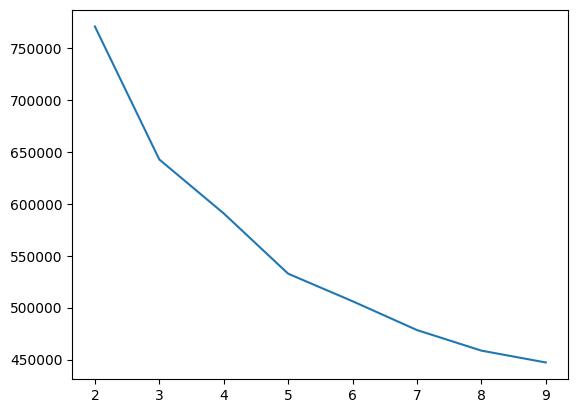

In [18]:
#Checking right clusters with elbow method
ssd = []
clusters_n = [2, 3, 4, 5, 6, 7, 8, 9]
for clusters in clusters_n:
    kmeans_model = KMeans(n_clusters=clusters, max_iter=300)
    kmeans_model.fit(X_Scaled)


    ssd.append(kmeans_model.inertia_)

plt.plot(clusters_n, ssd)
plt.show()


In [ ]:
#Checking right k with silhouette score which ranges from -1 to 1
#A score closer to 1 indicates that the data point is very similar to other data points in the cluster
clusters_n = [2, 3, 4, 5]
for clusters in clusters_n:
    kmeans_model = KMeans(n_clusters=clusters, max_iter=100)
    kmeans_model.fit(X_Scaled)
    model_labels = kmeans_model.labels_
    silhouette = silhouette_score(X_Scaled, model_labels)

    print(f'for clusters:{clusters} silhouette_score is:{silhouette}')

for clusters:2 silhouette_score is:0.20315408088994005
for clusters:3 silhouette_score is:0.2388529080760105
for clusters:4 silhouette_score is:0.22710128481075226
for clusters:5 silhouette_score is:0.18469568436135253


In [24]:
#Checking right k with davies_bouldin_score
#Lower is better
clusters_n = [2, 3, 4, 5, 6, 7]
for clusters in clusters_n:
    kmeans_model = KMeans(n_clusters=clusters, max_iter=100)
    kmeans_model.fit(X_Scaled)
    model_labels = kmeans_model.labels_
    davies = davies_bouldin_score(X_Scaled, model_labels)

    print(f'for clusters:{clusters} davies_bouldin_score is:{davies}')

for clusters:2 davies_bouldin_score is:1.943495151555676
for clusters:3 davies_bouldin_score is:1.5752854305584683
for clusters:4 davies_bouldin_score is:1.8401623855971607
for clusters:5 davies_bouldin_score is:1.7008540657327582
for clusters:6 davies_bouldin_score is:1.7208771517953645
for clusters:7 davies_bouldin_score is:1.669227599680309


By these three evaluation metrics it is clear that choosing k=3 is the correct choice

In [25]:
#Final Model with k=3
model = KMeans(n_clusters=3, max_iter=100)
model.fit(X_Scaled)


,n_clusters,3
,init,'k-means++'
,n_init,'auto'
,max_iter,100
,tol,0.0001
,verbose,0
,random_state,None
,copy_x,True
,algorithm,'lloyd'


In [ ]:
model.labels_ 

array([1, 1, 1, ..., 1, 1, 1], shape=(95495,), dtype=int32)

In [28]:
X['clusters'] = model.labels_ 
X.head()

,duration_ms,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,clusters
0,161427,0.563,0.184,-13.757,0.0512,0.993,0.000016,0.325,0.654,133.088,1
1,223440,0.427,0.180,-15.375,0.0670,0.989,0.000000,0.128,0.431,78.459,1
2,208267,0.511,0.206,-15.514,0.0592,0.995,0.000000,0.418,0.481,70.443,1
3,161933,0.676,0.467,-12.393,0.1650,0.991,0.000000,0.219,0.726,129.775,1
4,167973,0.650,0.298,-13.806,0.1380,0.991,0.000000,0.373,0.844,75.950,1


In [31]:
X.to_csv('D:\VSCODE\Project_Songs_Clustering\Music_Data_Clusters.csv', index=False)